# 04 - Error Analysis

Categorise evaluation failures into hallucination, retrieval miss, loop non-convergence, and safety false positive.

In [1]:
import json
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / 'experiments').exists():
    ROOT = Path('/teamspace/studios/this_studio')

eval_df = pd.read_csv(ROOT / 'experiments/model_free_eval_results.csv')
test_set = json.loads((ROOT / 'data/eval/test_set.json').read_text())
truth_by_question = {row['question']: row for row in test_set}
eval_df.head()

,question,answer,ground_truth,contexts,faithfulness,answer_relevancy,context_precision,context_recall
0,Are complex coronary lesions more frequent in ...,The prevalence of complex coronary lesions is ...,Complex coronary lesions such as bifurcation a...,['Coronary atherosclerotic burden is excessive...,0.9785,0.9300,1.0,0.9977
1,Are physicians aware of the side effects of an...,The source is a study that evaluated the knowl...,"Overall, there was a poor knowledge of the sid...",['Angiotensin-converting enzyme inhibitors (AC...,0.9986,0.7769,1.0,0.9978
2,Amblyopia: is visual loss permanent?,[41dcbb0f-acde-43b1-9d27-80afa78494b9] The imp...,Older people with a history of amblyopia who d...,['The improvement in acuity generally occurred...,0.9955,0.7809,1.0,0.9980
3,Parasacral sciatic nerve block: does the elici...,Parasacral sciatic nerve block: does the elici...,Eliciting a tibial motor response predicts a h...,['Sensory and motor blocks were assessed every...,0.9975,0.8047,1.0,0.9933
4,Does responsibility affect the public's valuat...,The source does not contain sufficient informa...,Our results suggest that people do not attach ...,['Health services often spend more on safety i...,0.9909,0.8123,1.0,0.9903


In [5]:
def categorise_failure(row):
    answer = str(row.get('answer', ''))
    truth = str(row.get('ground_truth', ''))
    faithfulness = float(row.get('faithfulness', 0.0))
    retries = int(row.get('avg_retries', row.get('retry_count', row.get('retries', 0))))

    if 'Medical disclaimer' in answer and 'diagnosis' not in truth.lower():
        return 'safety false positive'
    if retries >= 2 and faithfulness < 0.6:
        return 'loop non-convergence'
    if faithfulness < 0.5:
        return 'hallucination'
    return 'retrieval miss'

errors = eval_df.copy()
if 'avg_retries' not in errors.columns:
    if 'retry_count' in errors.columns:
        errors['avg_retries'] = errors['retry_count']
    elif 'retries' in errors.columns:
        errors['avg_retries'] = errors['retries']
    else:
        errors['avg_retries'] = 0

errors['failure_type'] = errors.apply(categorise_failure, axis=1)
errors[['question', 'faithfulness', 'avg_retries', 'failure_type']].head(20)

,question,faithfulness,avg_retries,failure_type
0,Are complex coronary lesions more frequent in ...,0.9785,0,retrieval miss
1,Are physicians aware of the side effects of an...,0.9986,0,retrieval miss
2,Amblyopia: is visual loss permanent?,0.9955,0,retrieval miss
3,Parasacral sciatic nerve block: does the elici...,0.9975,0,retrieval miss
4,Does responsibility affect the public's valuat...,0.9909,0,retrieval miss
5,Is zero central line-associated bloodstream in...,0.8547,0,retrieval miss
6,Are there mental health differences between fr...,0.9023,0,retrieval miss
7,Is perforation of the appendix a risk factor f...,0.9974,0,retrieval miss
8,Does case-mix based reimbursement stimulate th...,0.9533,0,retrieval miss
9,Cycloplegic autorefraction in young adults: is...,0.0657,0,hallucination


In [4]:
summary = errors['failure_type'].value_counts().rename_axis('failure_type').reset_index(name='count')
summary

,failure_type,count
0,retrieval miss,9
1,hallucination,1


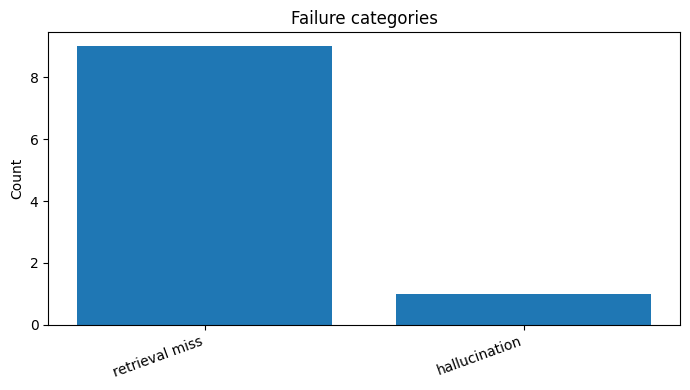

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(summary['failure_type'], summary['count'])
ax.set_title('Failure categories')
ax.set_ylabel('Count')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# 04 - Error Analysis
Run this notebook after evaluation results are generated in experiments/.

In [8]:
from pathlib import Path
import pandas as pd

CANDIDATES = [
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
    Path('/teamspace/studios/this_studio'),
]
ROOT = None
for candidate in CANDIDATES:
    if (candidate / 'experiments').exists() and (candidate / 'data').exists():
        ROOT = candidate.resolve()
        break

if ROOT is None:
    raise FileNotFoundError('Could not locate project root containing experiments/ and data/.')

path = ROOT / 'experiments/model_free_eval_results.csv'
if not path.exists():
    alt = ROOT / 'experiments/ragas_results.csv'
    if alt.exists():
        path = alt
    else:
        raise FileNotFoundError('Missing experiments/model_free_eval_results.csv (and ragas_results.csv). Run evaluation first.')

df = pd.read_csv(path)
metrics = ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']
df['mean_metric'] = df[metrics].mean(axis=1)
df.sort_values('mean_metric')[['question', 'mean_metric'] + metrics].head(15)

,question,mean_metric,faithfulness,answer_relevancy,context_precision,context_recall
9,Cycloplegic autorefraction in young adults: is...,0.642000,0.0657,0.5338,1.0,0.9685
8,Does case-mix based reimbursement stimulate th...,0.788300,0.9533,0.7006,0.5,0.9993
6,Are there mental health differences between fr...,0.927000,0.9023,0.8100,1.0,0.9957
7,Is perforation of the appendix a risk factor f...,0.934300,0.9974,0.7552,1.0,0.9846
1,Are physicians aware of the side effects of an...,0.943325,0.9986,0.7769,1.0,0.9978
5,Is zero central line-associated bloodstream in...,0.943525,0.8547,0.9245,1.0,0.9949
2,Amblyopia: is visual loss permanent?,0.943600,0.9955,0.7809,1.0,0.9980
4,Does responsibility affect the public's valuat...,0.948375,0.9909,0.8123,1.0,0.9903
3,Parasacral sciatic nerve block: does the elici...,0.948875,0.9975,0.8047,1.0,0.9933
0,Are complex coronary lesions more frequent in ...,0.976550,0.9785,0.9300,1.0,0.9977


In [9]:
worst = df.sort_values('mean_metric').head(5).copy()
worst[['question', 'answer', 'ground_truth', 'faithfulness', 'answer_relevancy']]

,question,answer,ground_truth,faithfulness,answer_relevancy
9,Cycloplegic autorefraction in young adults: is...,Cycloplegic autorefraction in young adults: is...,Young hypermetropic adults possessed +1 to +2 ...,0.0657,0.5338
8,Does case-mix based reimbursement stimulate th...,"No, the context does not contain sufficient in...",This study demonstrates that hospital manageme...,0.9533,0.7006
6,Are there mental health differences between fr...,DISCLAIMER: This response is generated from bi...,The discrepancy in how Francophones view their...,0.9023,0.8100
7,Is perforation of the appendix a risk factor f...,The source states that the raw data or specifi...,The methodologic weaknesses of the studies do ...,0.9974,0.7552
1,Are physicians aware of the side effects of an...,The source is a study that evaluated the knowl...,"Overall, there was a poor knowledge of the sid...",0.9986,0.7769


# 04 - Error Analysis
Analyze failure cases after evaluation outputs are available.

In [13]:
from pathlib import Path
import pandas as pd

CANDIDATES = [
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
    Path('/teamspace/studios/this_studio'),
]
ROOT = None
for candidate in CANDIDATES:
    if (candidate / 'experiments').exists() and (candidate / 'data').exists():
        ROOT = candidate.resolve()
        break

if ROOT is None:
    raise FileNotFoundError('Could not locate project root containing experiments/ and data/.')

mf_path = ROOT / 'experiments/model_free_eval_results.csv'
if not mf_path.exists():
    alt = ROOT / 'experiments/ragas_results.csv'
    if alt.exists():
        mf_path = alt
    else:
        raise FileNotFoundError('Run evaluation first: experiments/model_free_eval_results.csv not found.')

df = pd.read_csv(mf_path)
metrics = ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']
df['mean_metric'] = df[metrics].mean(axis=1)
df[['question', 'mean_metric'] + metrics].sort_values('mean_metric').head(15)

,question,mean_metric,faithfulness,answer_relevancy,context_precision,context_recall
9,Cycloplegic autorefraction in young adults: is...,0.642000,0.0657,0.5338,1.0,0.9685
8,Does case-mix based reimbursement stimulate th...,0.788300,0.9533,0.7006,0.5,0.9993
6,Are there mental health differences between fr...,0.927000,0.9023,0.8100,1.0,0.9957
7,Is perforation of the appendix a risk factor f...,0.934300,0.9974,0.7552,1.0,0.9846
1,Are physicians aware of the side effects of an...,0.943325,0.9986,0.7769,1.0,0.9978
5,Is zero central line-associated bloodstream in...,0.943525,0.8547,0.9245,1.0,0.9949
2,Amblyopia: is visual loss permanent?,0.943600,0.9955,0.7809,1.0,0.9980
4,Does responsibility affect the public's valuat...,0.948375,0.9909,0.8123,1.0,0.9903
3,Parasacral sciatic nerve block: does the elici...,0.948875,0.9975,0.8047,1.0,0.9933
0,Are complex coronary lesions more frequent in ...,0.976550,0.9785,0.9300,1.0,0.9977


In [14]:
worst = df.sort_values('mean_metric').head(5).copy()
worst[['question', 'answer', 'ground_truth', 'faithfulness', 'answer_relevancy']]

,question,answer,ground_truth,faithfulness,answer_relevancy
9,Cycloplegic autorefraction in young adults: is...,Cycloplegic autorefraction in young adults: is...,Young hypermetropic adults possessed +1 to +2 ...,0.0657,0.5338
8,Does case-mix based reimbursement stimulate th...,"No, the context does not contain sufficient in...",This study demonstrates that hospital manageme...,0.9533,0.7006
6,Are there mental health differences between fr...,DISCLAIMER: This response is generated from bi...,The discrepancy in how Francophones view their...,0.9023,0.8100
7,Is perforation of the appendix a risk factor f...,The source states that the raw data or specifi...,The methodologic weaknesses of the studies do ...,0.9974,0.7552
1,Are physicians aware of the side effects of an...,The source is a study that evaluated the knowl...,"Overall, there was a poor knowledge of the sid...",0.9986,0.7769


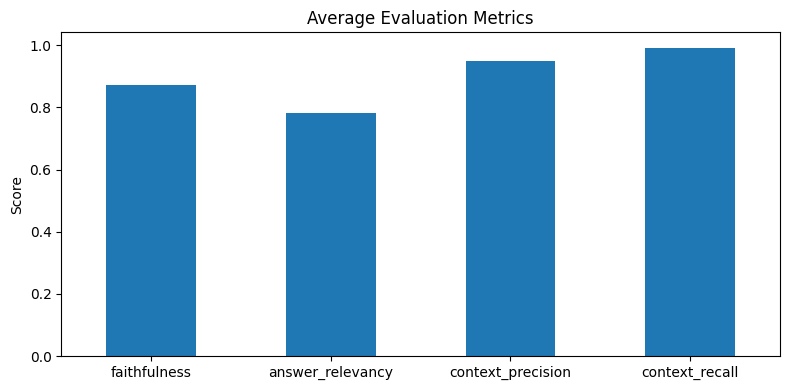

In [15]:
import matplotlib.pyplot as plt

ax = df[metrics].mean().plot(kind='bar', figsize=(8, 4), rot=0)
ax.set_title('Average Evaluation Metrics')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()